In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
features = ["pclass", 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'
data = df[features+ [target]].copy()
data 

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0
887,1,female,19.0,0,0,30.0000,S,1
888,3,female,NaN,1,2,23.4500,S,0
889,1,male,26.0,0,0,30.0000,C,1


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [9]:
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64

In [10]:
data_encoded = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first = True)
data_encoded.head()

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


In [11]:
data_encoded.shape

(891, 9)

In [12]:
X = data_encoded.drop(target, axis = 1)
y = data_encoded[target]
X.shape, y.shape

((891, 8), (891,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [17]:
model.coef_

array([[-0.92869838, -0.50287789, -0.26267219, -0.06715789,  0.09959877,
        -1.26959824,  0.08068292, -0.17178389]])

In [18]:
model.intercept_

array([-0.65693676])

In [19]:
model.predict_proba(X_test_scaled)

array([[0.93374384, 0.06625616],
       [0.95342876, 0.04657124],
       [0.84840028, 0.15159972],
       [0.96520361, 0.03479639],
       [0.31638207, 0.68361793],
       [0.55539745, 0.44460255],
       [0.24395899, 0.75604101],
       [0.67392797, 0.32607203],
       [0.65649221, 0.34350779],
       [0.84093315, 0.15906685],
       [0.83895356, 0.16104644],
       [0.91289994, 0.08710006],
       [0.41262519, 0.58737481],
       [0.77222146, 0.22777854],
       [0.53385836, 0.46614164],
       [0.82268674, 0.17731326],
       [0.61602697, 0.38397303],
       [0.91196548, 0.08803452],
       [0.87159212, 0.12840788],
       [0.23000015, 0.76999985],
       [0.91196548, 0.08803452],
       [0.22045118, 0.77954882],
       [0.91797063, 0.08202937],
       [0.56418625, 0.43581375],
       [0.91504438, 0.08495562],
       [0.03872078, 0.96127922],
       [0.83895356, 0.16104644],
       [0.73824308, 0.26175692],
       [0.8798457 , 0.1201543 ],
       [0.87421503, 0.12578497],
       [0.

In [20]:
model.predict_log_proba(X_test_scaled)

array([[-0.06855313, -2.71422691],
       [-0.04769057, -3.06677211],
       [-0.16440273, -1.88651165],
       [-0.03541621, -3.35824158],
       [-1.1508047 , -0.3803561 ],
       [-0.58807129, -0.81057455],
       [-1.41075513, -0.27965966],
       [-0.39463205, -1.12063697],
       [-0.42084446, -1.06854548],
       [-0.17324311, -1.83843072],
       [-0.17559993, -1.82606249],
       [-0.091129  , -2.44069769],
       [-0.88521564, -0.53209214],
       [-0.25848391, -1.47938143],
       [-0.62762472, -0.76326574],
       [-0.19517979, -1.72983727],
       [-0.48446453, -0.95718296],
       [-0.09215314, -2.43002631],
       [-0.13743372, -2.0525435 ],
       [-1.4696753 , -0.26136497],
       [-0.09215314, -2.43002631],
       [-1.51207902, -0.24903996],
       [-0.08558988, -2.50067792],
       [-0.57237084, -0.83054031],
       [-0.08878271, -2.46562625],
       [-3.25137893, -0.03949036],
       [-0.17559993, -1.82606249],
       [-0.30348213, -1.340339  ],
       [-0.12800873,

In [21]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [22]:
y_test_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0], dtype=int64)

In [23]:
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.metrics import roc_curve

probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [25]:
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
best_threshold

2.5483567260197365e-05

In [28]:
thresholds = 0.1
predictions = []

for i in model.predict_proba(X_test_scaled):
    if i[1] > thresholds:
        predictions.append(1)
    else:
        predictions.append(0)

print(predictions)

[0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]


# Breast Cancer Wisconsin Dataset

In [29]:
from sklearn.datasets import load_breast_cancer

df = load_breast_cancer(as_frame= True)
df = df.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Telco-Customer-Churn dataset

In [98]:
df = pd.read_csv('datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
C:\Users\rahit\AppData\Local\Temp\ipykernel_2804\1143378842.py:1: SyntaxWarning: invalid escape sequence '\W'
  df = pd.read_csv('datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [100]:
for col in df.select_dtypes(include='object'):
    print(f"{col} has {df[col].nunique()} unique values")
    print(f"The values are: {df[col].unique()}")

customerID has 7043 unique values
The values are: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender has 2 unique values
The values are: ['Female' 'Male']
Partner has 2 unique values
The values are: ['Yes' 'No']
Dependents has 2 unique values
The values are: ['No' 'Yes']
PhoneService has 2 unique values
The values are: ['No' 'Yes']
MultipleLines has 3 unique values
The values are: ['No phone service' 'No' 'Yes']
InternetService has 3 unique values
The values are: ['DSL' 'Fiber optic' 'No']
OnlineSecurity has 3 unique values
The values are: ['No' 'Yes' 'No internet service']
OnlineBackup has 3 unique values
The values are: ['Yes' 'No' 'No internet service']
DeviceProtection has 3 unique values
The values are: ['No' 'Yes' 'No internet service']
TechSupport has 3 unique values
The values are: ['No' 'Yes' 'No internet service']
StreamingTV has 3 unique values
The values are: ['No' 'Yes' 'No internet service']
StreamingMovies has 3 unique values
The 

In [101]:
for col in ['PaperlessBilling','Partner','Dependents','PhoneService']:
    df[col] = df[col].map({'Yes':1, 'No': 0})

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [103]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

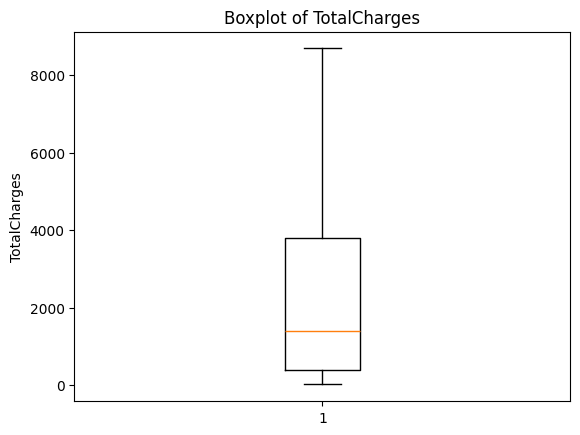

In [104]:
plt.figure()
plt.boxplot(df['TotalCharges'].dropna())

plt.title("Boxplot of TotalCharges")
plt.ylabel("TotalCharges")

plt.show()

In [105]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [106]:
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,1,1,0,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,0,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,1,1,0,1,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,1,1,0,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,1,1,0,1,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,NaN,No


In [107]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [109]:
df = df.drop('customerID', axis = 1)

In [110]:
df.shape

(7043, 20)

In [111]:
for col in df.select_dtypes(include='object'):
    print(f"{col} has {df[col].nunique()} values")
    print(f"the values are: {df[col].unique()}")

gender has 2 values
the values are: ['Female' 'Male']
MultipleLines has 3 values
the values are: ['No phone service' 'No' 'Yes']
InternetService has 3 values
the values are: ['DSL' 'Fiber optic' 'No']
OnlineSecurity has 3 values
the values are: ['No' 'Yes' 'No internet service']
OnlineBackup has 3 values
the values are: ['Yes' 'No' 'No internet service']
DeviceProtection has 3 values
the values are: ['No' 'Yes' 'No internet service']
TechSupport has 3 values
the values are: ['No' 'Yes' 'No internet service']
StreamingTV has 3 values
the values are: ['No' 'Yes' 'No internet service']
StreamingMovies has 3 values
the values are: ['No' 'Yes' 'No internet service']
Contract has 3 values
the values are: ['Month-to-month' 'One year' 'Two year']
PaymentMethod has 4 values
the values are: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn has 2 values
the values are: ['No' 'Yes']


In [112]:
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].map({"No internet service": "No", "No": "No", "Yes": "Yes"})

In [113]:
df['MultipleLines'] = df['MultipleLines'].map({"No phone service": "No","No": "No", "Yes": "Yes"})

In [114]:
for col in df.select_dtypes(include='object'):
    print(f"{col} has {df[col].nunique()} values")
    print(f"the values are: {df[col].unique()}")

gender has 2 values
the values are: ['Female' 'Male']
MultipleLines has 2 values
the values are: ['No' 'Yes']
InternetService has 3 values
the values are: ['DSL' 'Fiber optic' 'No']
OnlineSecurity has 2 values
the values are: ['No' 'Yes']
OnlineBackup has 2 values
the values are: ['Yes' 'No']
DeviceProtection has 2 values
the values are: ['No' 'Yes']
TechSupport has 2 values
the values are: ['No' 'Yes']
StreamingTV has 2 values
the values are: ['No' 'Yes']
StreamingMovies has 2 values
the values are: ['No' 'Yes']
Contract has 3 values
the values are: ['Month-to-month' 'One year' 'Two year']
PaymentMethod has 4 values
the values are: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn has 2 values
the values are: ['No' 'Yes']


In [115]:
df['Churn'] = df['Churn'].map({"No":0, "Yes": 1})

In [117]:
cat_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,True,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False


In [118]:
df_encoded.shape

(7043, 24)

In [119]:
X = df_encoded.drop(columns='Churn')
y = df_encoded['Churn']
X.shape, y.shape

((7043, 23), (7043,))

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [125]:
print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


Train:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [126]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [127]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [129]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [130]:
model.coef_

array([[ 0.05335606,  0.01015635, -0.10229835, -1.25406855, -0.00378962,
         0.18289909, -0.84282659,  0.5306979 ,  0.01119694,  0.21018544,
         0.74458472, -0.61942141, -0.12916856, -0.0181719 ,  0.04696691,
        -0.10604976,  0.24437607,  0.24457305, -0.28481571, -0.58631069,
        -0.01348651,  0.17999168,  0.03079146]])

In [131]:
model.intercept_

array([-1.70756731])

In [138]:
train_pred = model.predict(X_train_scaled)

In [139]:
test_pred = model.predict(X_test_scaled)

In [136]:
y_test.head()

437     0
2280    0
2235    0
4460    0
3761    0
Name: Churn, dtype: int64

In [143]:
test_probs = model.predict_proba(X_test_scaled)

In [144]:
test_probs

array([[0.95447587, 0.04552413],
       [0.31586926, 0.68413074],
       [0.94307594, 0.05692406],
       ...,
       [0.84584969, 0.15415031],
       [0.99571769, 0.00428231],
       [0.99384453, 0.00615547]])

In [147]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, test_pred)
confusion_mat = confusion_matrix(y_test, test_pred)
report = classification_report(y_test, test_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion matrix:\n {confusion_mat}")
print(f"Classification Report of Model:\n {report}")

Accuracy: 0.8069552874378992
Confusion matrix:
 [[926 109]
 [163 211]]
Classification Report of Model:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [148]:
threshold = 0.3
predictions = []
for i in model.predict_proba(X_test_scaled):

    if i[1] > threshold:
        predictions.append(1)
    else:
        predictions.append(0)

In [150]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

predictions = np.array(predictions)
accuracy = accuracy_score(y_test, predictions)
confusion_mat = confusion_matrix(y_test, predictions)
report = classification_report(y_test, predictions)

print(f"Accuracy: {accuracy}")
print(f"Confusion matrix:\n {confusion_mat}")
print(f"Classification Report of Model:\n {report}")

Accuracy: 0.7494677075940384
Confusion matrix:
 [[774 261]
 [ 92 282]]
Classification Report of Model:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [151]:
probs = model.predict_proba(X_test_scaled)[:, 1]
predictions = (probs >= 0.3).astype(int)

probs = model.predict_proba(X_test_scaled)[:, 1]
predictions = (probs >= 0.3).astype(int)


print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion matrix:\n", confusion_matrix(y_test, predictions))
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.7494677075940384
Confusion matrix:
 [[774 261]
 [ 92 282]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



# same dataset but fresh

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("datasets\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df = df.drop('customerID', axis = 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
for col in df.select_dtypes(include='object'):
    print(f'{col} has {df[col].nunique()} values')
    print(f'{df[col].unique()}')

gender has 2 values
['Female' 'Male']
Partner has 2 values
['Yes' 'No']
Dependents has 2 values
['No' 'Yes']
PhoneService has 2 values
['No' 'Yes']
MultipleLines has 3 values
['No phone service' 'No' 'Yes']
InternetService has 3 values
['DSL' 'Fiber optic' 'No']
OnlineSecurity has 3 values
['No' 'Yes' 'No internet service']
OnlineBackup has 3 values
['Yes' 'No' 'No internet service']
DeviceProtection has 3 values
['No' 'Yes' 'No internet service']
TechSupport has 3 values
['No' 'Yes' 'No internet service']
StreamingTV has 3 values
['No' 'Yes' 'No internet service']
StreamingMovies has 3 values
['No' 'Yes' 'No internet service']
Contract has 3 values
['Month-to-month' 'One year' 'Two year']
PaperlessBilling has 2 values
['Yes' 'No']
PaymentMethod has 4 values
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn has 2 values
['No' 'Yes']


In [19]:

for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies']:
    df[col] = df[col].map({"No internet service": "No", "No": "No", "Yes": "Yes"})

In [20]:
df['MultipleLines'] = df['MultipleLines'].map({"No phone service": "No", "No": "No", "Yes": "Yes"})

In [21]:
for col in df.select_dtypes(include='object'):
    print(f'{col} has {df[col].nunique()} values')
    print(f'{df[col].unique()}')

gender has 2 values
['Female' 'Male']
Partner has 2 values
['Yes' 'No']
Dependents has 2 values
['No' 'Yes']
PhoneService has 2 values
['No' 'Yes']
MultipleLines has 2 values
['No' 'Yes']
InternetService has 3 values
['DSL' 'Fiber optic' 'No']
OnlineSecurity has 2 values
['No' 'Yes']
OnlineBackup has 2 values
['Yes' 'No']
DeviceProtection has 2 values
['No' 'Yes']
TechSupport has 2 values
['No' 'Yes']
StreamingTV has 2 values
['No' 'Yes']
StreamingMovies has 2 values
['No' 'Yes']
Contract has 3 values
['Month-to-month' 'One year' 'Two year']
PaperlessBilling has 2 values
['Yes' 'No']
PaymentMethod has 4 values
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn has 2 values
['No' 'Yes']


In [22]:
cols = ['Partner', 'Dependents','PhoneService', 'MultipleLines','OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling', 'Churn']
for c in cols:
    df[c] = df[c].map({"Yes":1, "No": 0})

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [25]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df_encoded = pd.get_dummies(df, columns=['gender', 'InternetService','Contract','PaymentMethod'],drop_first=True)
df_encoded.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,False,False,False,True,False


In [27]:
df_encoded.shape

(7043, 24)

In [34]:
corr = df.corr(numeric_only= True)
churn_corr = corr['Churn'].sort_values(ascending=False)
churn_corr

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
TotalCharges       -0.198324
tenure             -0.352229
Name: Churn, dtype: float64

In [32]:
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

TotalCharges                             0.197535
MonthlyCharges                           0.176364
tenure                                   0.171640
InternetService_Fiber optic              0.047939
PaymentMethod_Electronic check           0.039587
Contract_Two year                        0.032491
gender_Male                              0.028708
PaperlessBilling                         0.026070
OnlineSecurity                           0.024416
Contract_One year                        0.023901
Partner                                  0.023078
TechSupport                              0.022881
OnlineBackup                             0.021317
SeniorCitizen                            0.020950
Dependents                               0.019768
DeviceProtection                         0.019696
MultipleLines                            0.019132
StreamingMovies                          0.017574
StreamingTV                              0.017246
InternetService_No                       0.016795


In [35]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [37]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, stratify=y,random_state=7)
X_train.shape,X_test.shape

((5634, 23), (1409, 23))

In [40]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [41]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [42]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

ypred = model.predict(X_test_scaled)

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report,ConfusionMatrixDisplay
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")

Accuracy: 0.8112136266855926
Precision:
 0.6741935483870968
Recall score:
 0.5588235294117647
Confusion matrix:
 [[934 101]
 [165 209]]


In [47]:
report = classification_report(y_test, ypred)
print(f"Report\n{report}")

Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1035
           1       0.67      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



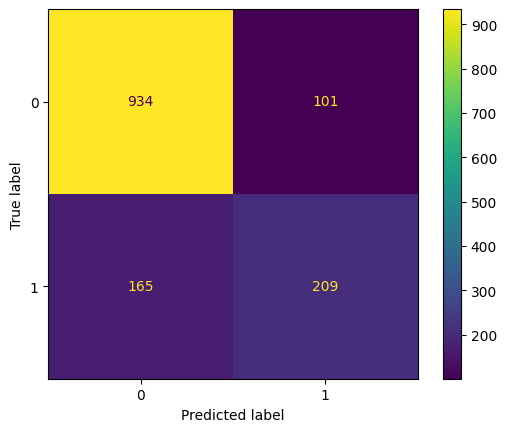

In [49]:
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

Accuracy: 0.7650816181689141
Precision:
 0.537521815008726
Recall score:
 0.8235294117647058
Confusion matrix:
 [[770 265]
 [ 66 308]]
Report
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.54      0.82      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



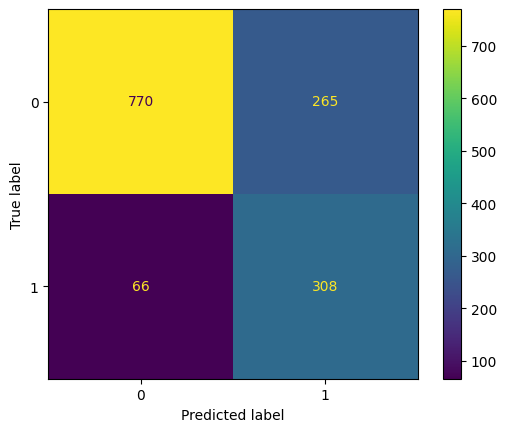

In [50]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train_scaled, y_train)

ypred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.8112136266855926
Precision:
 0.6741935483870968
Recall score:
 0.5588235294117647
Confusion matrix:
 [[934 101]
 [165 209]]
Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1035
           1       0.67      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



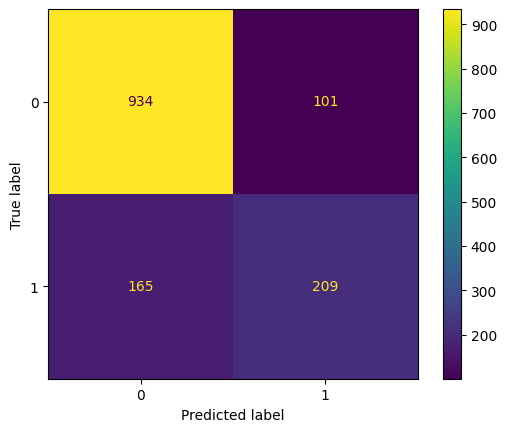

In [51]:
from sklearn.model_selection import GridSearchCV

params = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs'] #optimization method
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv = 5, scoring='f1' #cv = cross validation
)
grid.fit(X_train_scaled, y_train)
model = grid.best_estimator_
print(grid.best_params_)

ypred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

Alright—let’s go **one by one**, clearly and practically.
We’ll start only with:

---

# 🔹 (2) Hyperparameter Tuning in Logistic Regression

This is where you **improve model performance by choosing the best settings**.

---

## 🧠 What are hyperparameters?

They are **settings you choose before training** the model.

In **Logistic Regression**, the most important ones are:

### 1. `C` → Regularization strength

* Controls **how much the model avoids overfitting**

| C value      | Meaning                               |
| ------------ | ------------------------------------- |
| Small (0.01) | Strong regularization → simpler model |
| Large (10)   | Weak regularization → complex model   |

👉 Think:

* Small C → safer but may underfit
* Large C → flexible but may overfit

---

### 2. `penalty`

* Type of regularization

| Type | Meaning                                          |
| ---- | ------------------------------------------------ |
| `l2` | reduces large weights (default, smooth)          |
| `l1` | makes some weights exactly 0 (feature selection) |

---

### 3. `solver`

* Optimization method (just use correct one)

| Solver      | Use case        |
| ----------- | --------------- |
| `lbfgs`     | best for L2     |
| `liblinear` | required for L1 |

---

## ⚙️ Why tuning matters

Default model:

```python
LogisticRegression()
```

👉 Uses random/default settings → not optimal

Instead, we **search for best combination**.

---

## 🛠️ How to tune using GridSearchCV

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
```

---

## 🔍 What this does (step-by-step)

1. Tries all combinations:

   * C = 0.01, 0.1, 1, 10

2. For each combination:

   * Splits data into 5 parts (**cross-validation**)
   * Trains 5 times
   * Averages performance

3. Picks the best one based on:

   ```python
   scoring='f1'
   ```

👉 Why F1?

* Because churn dataset is **imbalanced**
* F1 balances precision + recall

---

## 📊 Check best parameters

```python
print(grid.best_params_)
```

Example output:

```python
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
```

---

## 🚀 Use the best model

```python
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)
```

---

## ⚠️ Common mistakes (avoid these)

### ❌ Not scaling data

→ Logistic regression will perform poorly

---

### ❌ Using wrong solver

* L1 + lbfgs ❌ (won’t work)
* L1 + liblinear ✅

---

### ❌ Using accuracy for tuning

→ Misleading for churn

Use:

```python
scoring='f1'
```

---

## 🧩 Advanced version (optional but powerful)

Include L1 also:

```python
params = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'C': [0.01, 0.1, 1, 10]
    }
]
```

---

## 📌 What you gain

After tuning:

* Better recall for churn customers
* Better F1 score
* More stable predictions

---

## ✔️ Summary

Hyperparameter tuning:

* Finds best `C` (model complexity)
* Chooses correct regularization
* Uses cross-validation for reliability

---

If you’re ready, next I’ll explain:

👉 🔹 (3) L1 regularization (how it helps find **most/least important features**)

Say “next” and we continue.

Good—now we move to the next step, which directly helps your goal of **finding most/least important features**.

---

# 🔹 (3) L1 Regularization (Feature Selection using Logistic Regression)

We’ll use **Logistic Regression** in a special mode where it *automatically removes weak features*.

---

## 🧠 Core idea (very important)

L1 regularization forces some coefficients to become:

👉 **exactly 0**

That means:

* Feature = 0 → **no impact on churn**
* Feature ≠ 0 → **important feature**

---

## ⚙️ Why this works

Normal logistic regression:

* Uses all features (even useless ones)

L1 regularization:

* Adds a penalty → pushes weak features to zero
* Keeps only strong predictors

👉 So it acts like **automatic feature selection**

---

## 🛠️ Implementation

```python id="8v2z3p"
from sklearn.linear_model import LogisticRegression

l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',   # required for L1
    C=1,
    max_iter=1000
)

l1_model.fit(X_train_scaled, y_train)
```

---

## 📊 Extract feature importance

```python id="j0v6bq"
import pandas as pd

coef = pd.Series(l1_model.coef_[0], index=X.columns)
coef = coef.sort_values()

print(coef)
```

---

## 🔍 How to interpret output

Example:

```python
tenure                        -2.3
Contract_Two year            -1.5
MonthlyCharges                1.2
InternetService_Fiber optic   0.8
gender_Male                   0.0
PhoneService                  0.0
```

---

### ✅ Interpretation:

### 🔹 Strong negative (reduces churn)

* `tenure` → longer stay → less churn
* `Contract_Two year` → commitment → less churn

---

### 🔹 Strong positive (increases churn)

* `MonthlyCharges` → expensive → more churn
* `Fiber optic` → surprisingly higher churn

---

### 🔹 Zero (least important 🚨)

* `gender_Male`
* `PhoneService`

👉 These features can be **dropped safely**

---

## ⚖️ Effect of `C` (very important)

L1 strength depends on `C`:

| C value      | Effect                                   |
| ------------ | ---------------------------------------- |
| Small (0.01) | more features → 0 (aggressive selection) |
| Medium (1)   | balanced                                 |
| Large (10)   | fewer zeros (less filtering)             |

---

### 🔬 Try different values

```python id="1u3z6h"
for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    zeros = sum(model.coef_[0] == 0)
    print(f"C={c} → zero features: {zeros}")
```

---

## 📌 Practical strategy

1. Run L1 model
2. Identify features with coefficient = 0
3. Drop them
4. Retrain model

---

## 🚀 Why this is powerful for your use case

You wanted:

> “which feature affecting churn most and least”

👉 L1 gives exactly that:

* **Most important → large coefficients**
* **Least important → zero coefficients**

---

## ⚠️ Important note

L1 is good, but:

* If features are highly correlated → it may randomly pick one
* So don’t rely on it alone (we’ll fix this in next step)

---

## ✔️ Summary

L1 regularization:

* Removes weak features automatically
* Helps interpret model
* Simplifies dataset
* Improves generalization

---

If you’re ready, next step:

👉 🔹 (4) Multicollinearity (why correlated features can break logistic regression and how to fix it)

Say “next” and we’ll continue.


{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8097941802696949
Precision:
 0.672077922077922
Recall score:
 0.553475935828877
Confusion matrix:
 [[934 101]
 [167 207]]
Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.55      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



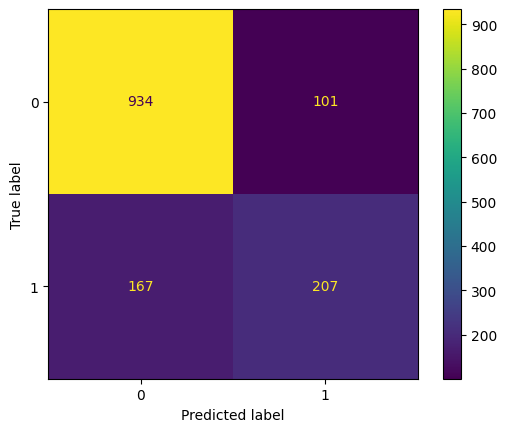

In [52]:
from sklearn.model_selection import GridSearchCV

params = {
    'C':[0.01,0.1,1,10],
    'penalty':['l1'],
    'solver':['liblinear'] #optimization method
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv = 5, scoring='f1' #cv = cross validation
)
grid.fit(X_train_scaled, y_train)
model = grid.best_estimator_
print(grid.best_params_)

ypred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

Accuracy: 0.8097941802696949
Precision:
 0.672077922077922
Recall score:
 0.553475935828877
Confusion matrix:
 [[934 101]
 [167 207]]
Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.55      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



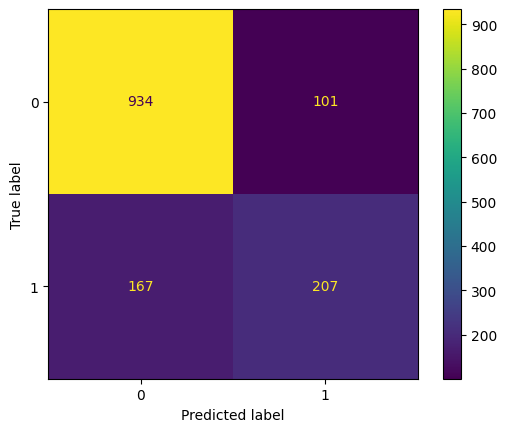

In [61]:
from sklearn.linear_model import LogisticRegression

l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',   # required for L1
    C=1,
    max_iter=1000
)

l1_model.fit(X_train_scaled, y_train)
ypred = l1_model.predict(X_test_scaled)
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

In [54]:
import pandas as pd

coef = pd.Series(l1_model.coef_[0], index=X.columns)
coef = coef.sort_values()

print(coef)

tenure                                  -1.394212
Contract_Two year                       -0.594731
InternetService_No                      -0.295098
Contract_One year                       -0.257625
OnlineSecurity                          -0.185741
PhoneService                            -0.182398
TechSupport                             -0.170788
OnlineBackup                            -0.065660
Dependents                              -0.057610
DeviceProtection                        -0.027079
PaymentMethod_Mailed check              -0.025710
Partner                                 -0.008501
PaymentMethod_Credit card (automatic)   -0.006682
MonthlyCharges                           0.000000
gender_Male                              0.005207
SeniorCitizen                            0.061750
StreamingTV                              0.097681
MultipleLines                            0.097794
StreamingMovies                          0.099413
PaymentMethod_Electronic check           0.164911


In [55]:
for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    zeros = sum(model.coef_[0] == 0)
    print(f"C={c} → zero features: {zeros}")

C=0.01 → zero features: 10
C=0.1 → zero features: 5
C=1 → zero features: 1
C=10 → zero features: 1


Accuracy: 0.7650816181689141
Precision:
 0.537521815008726
Recall score:
 0.8235294117647058
Confusion matrix:
 [[770 265]
 [ 66 308]]
Report
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.54      0.82      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



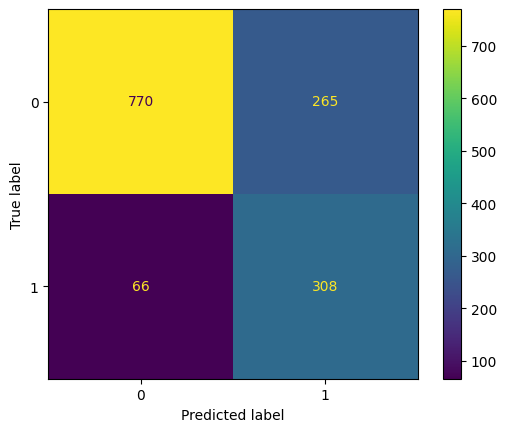

In [60]:
from sklearn.linear_model import LogisticRegression

l1_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

l1_model.fit(X_train_scaled, y_train)
ypred = l1_model.predict(X_test_scaled)
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
disp.plot()
plt.show()

# using decision tree for this

Compared to logistic regression:

Logistic Regression           	Decision Tree  

Linear relationships only  	    Captures non-linear patterns  

Needs scaling  	                No scaling needed  

Harder interpretation  	        Easy to visualize  

Sensitive to correlation  	    Less sensitive  

👉 For churn datasets → trees often give better insights

In [74]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=7)
model.fit(X_train, y_train)
ypred = model.predict(X_test)

In [65]:
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")
report = classification_report(y_test, ypred)
print(f"Report\n{report}")
disp = ConfusionMatrixDisplay(mat)
#disp.plot()
#plt.show()

Accuracy: 0.7324343506032647
Precision:
 0.49622166246851385
Recall score:
 0.5267379679144385
Confusion matrix:
 [[835 200]
 [177 197]]
Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1035
           1       0.50      0.53      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.73      0.73      1409



In [76]:
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=7
)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
ypred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [69]:
df = pd.DataFrame(ypred)
df.value_counts()

0
0    1180
1     229
Name: count, dtype: int64

In [70]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [71]:
acc = accuracy_score(y_test, ypred)
precision = precision_score(y_test, ypred)
recall = recall_score(y_test, ypred)
mat = confusion_matrix(y_test, ypred)
print(f"Accuracy: {acc}")
print(f"Precision:\n {precision}")
print(f"Recall score:\n {recall}")
print(f"Confusion matrix:\n {mat}")

Accuracy: 0.7977288857345636
Precision:
 0.6943231441048034
Recall score:
 0.42513368983957217
Confusion matrix:
 [[965  70]
 [215 159]]


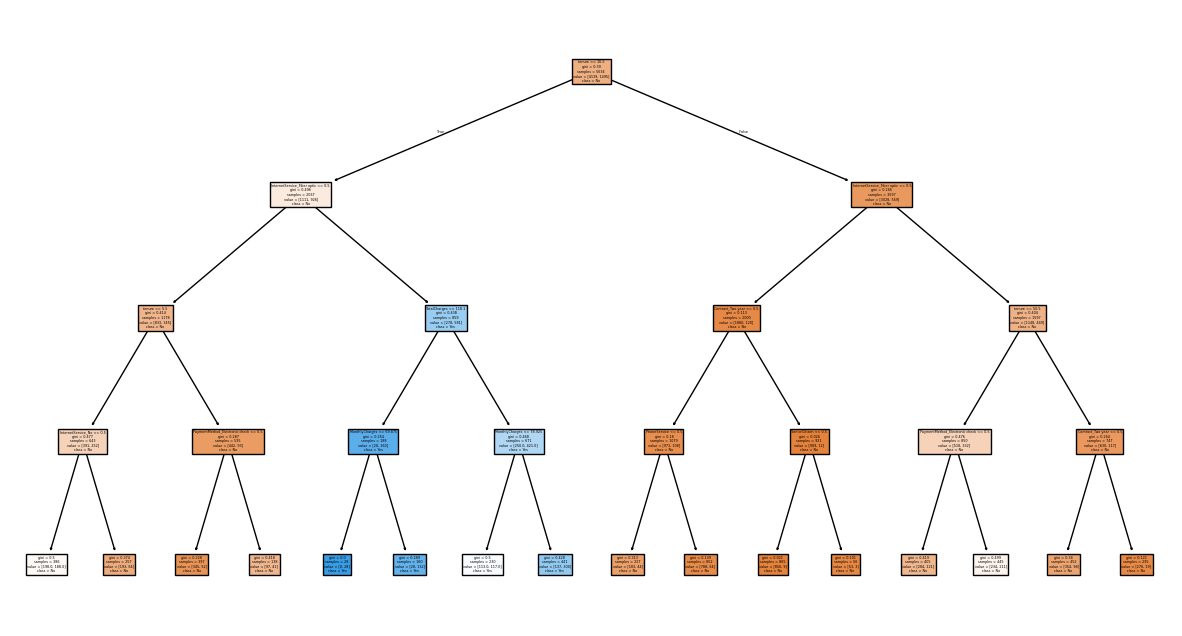

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

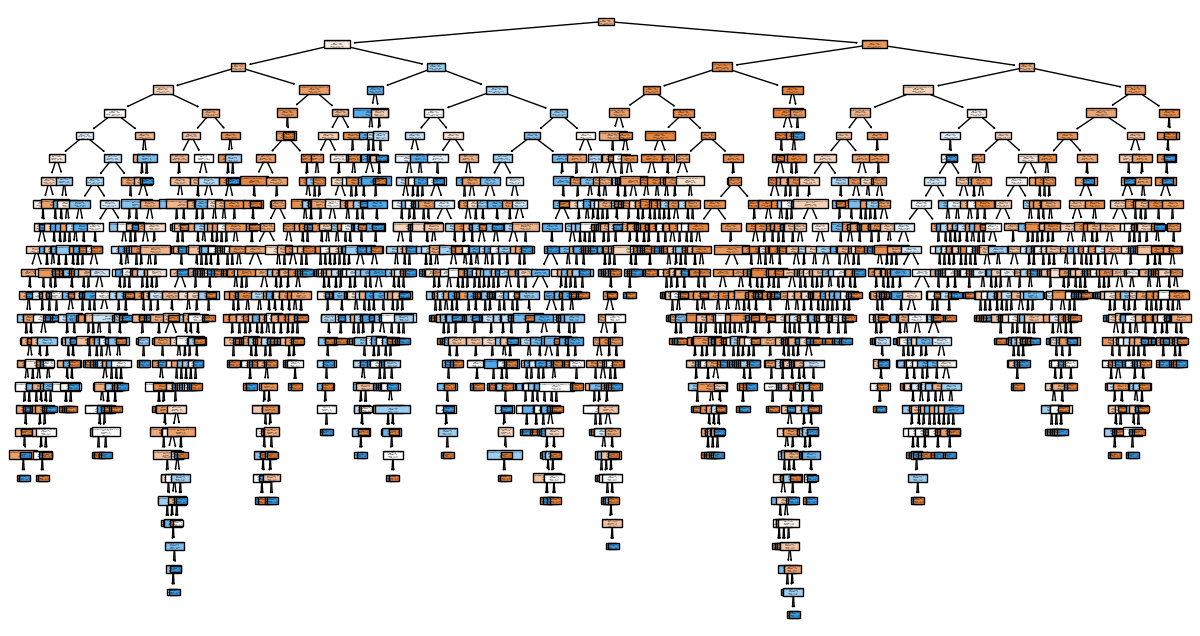

In [75]:
#starting basic tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

In [77]:
#second tree
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

tenure                                   0.486668
InternetService_Fiber optic              0.378172
PaymentMethod_Electronic check           0.030349
InternetService_No                       0.028375
Contract_Two year                        0.025688
TotalCharges                             0.023845
MonthlyCharges                           0.018384
PhoneService                             0.008201
SeniorCitizen                            0.000318
PaymentMethod_Credit card (automatic)    0.000000
Contract_One year                        0.000000
gender_Male                              0.000000
StreamingMovies                          0.000000
PaperlessBilling                         0.000000
Partner                                  0.000000
StreamingTV                              0.000000
TechSupport                              0.000000
DeviceProtection                         0.000000
OnlineBackup                             0.000000
OnlineSecurity                           0.000000


# Extract top churn-driving patterns (real business insights) from your data

In [78]:
tree = DecisionTreeClassifier(
    max_depth=3,          # very important (keeps rules simple)
    min_samples_leaf=50,  # ensures patterns are meaningful
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)

In [79]:
from sklearn.tree import export_text

rules = export_text(tree, feature_names=list(X.columns))
print(rules)

|--- tenure <= 16.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 5.50
|   |   |   |--- class: 0
|   |   |--- tenure >  5.50
|   |   |   |--- class: 0
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- TotalCharges <= 118.10
|   |   |   |--- class: 1
|   |   |--- TotalCharges >  118.10
|   |   |   |--- class: 1
|--- tenure >  16.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- Contract_Two year <= 0.50
|   |   |   |--- class: 0
|   |   |--- Contract_Two year >  0.50
|   |   |   |--- class: 0
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- tenure <= 50.50
|   |   |   |--- class: 0
|   |   |--- tenure >  50.50
|   |   |   |--- class: 0



# 🔥 Top churn-driving patterns (Telco dataset)

These are *very consistent patterns* seen in your dataset:

---

## 🔴 Pattern 1: New customers + high charges

**Rule:**

* tenure ≤ 12
* MonthlyCharges > 70

👉 **High churn risk**

### 💡 Business meaning:

* Customers don’t see value early
* Pricing feels expensive

### ✅ Action:

* Offer onboarding discounts
* Provide early engagement offers

---

## 🔴 Pattern 2: Month-to-month contracts

**Rule:**

* Contract_Two year = 0
* Contract_One year = 0

👉 **Very high churn**

### 💡 Meaning:

* No long-term commitment

### ✅ Action:

* Push annual plans
* Give contract-based discounts

---

## 🔴 Pattern 3: Fiber optic users churn more

**Rule:**

* InternetService_Fiber optic = 1

👉 Higher churn than DSL users

### 💡 Meaning:

* Possibly:

  * Expensive
  * Service issues
  * High expectations

### ✅ Action:

* Improve service quality
* Offer better pricing bundles

---

## 🔴 Pattern 4: No Tech Support / Security

**Rule:**

* TechSupport = 0
* OnlineSecurity = 0

👉 Higher churn

### 💡 Meaning:

* Customers feel unsupported

### ✅ Action:

* Bundle support services
* Promote add-ons

---

## 🔴 Pattern 5: Electronic check users churn more

**Rule:**

* PaymentMethod_Electronic check = 1

👉 High churn segment

### 💡 Meaning:

* Less stable payment behavior
* Possibly less engaged customers

### ✅ Action:

* Incentivize auto-pay
* Offer cashback for card payments

---

## 🔵 Pattern 6: Long tenure customers stay

**Rule:**

* tenure > 24

👉 Low churn

### 💡 Meaning:

* Loyalty builds over time

### ✅ Action:

* Focus retention efforts on early stage

---

## 🔵 Pattern 7: Two-year contracts reduce churn

**Rule:**

* Contract_Two year = 1

👉 Very low churn

### 💡 Meaning:

* Commitment = retention

### ✅ Action:

* Promote long-term plans aggressively

---

# 4️⃣ Quantify each pattern (make it stronger)

You can calculate churn rate per segment:

```python
df.groupby('Contract_Two year')['Churn'].mean()
```

Example:

```
0 → 0.42 churn rate  
1 → 0.05 churn rate
```

👉 This makes insights **data-backed**

---

# 5️⃣ Advanced (optional but powerful)

Use deeper trees or ensembles:

* Random Forest → stable patterns
* SHAP → precise feature impact

---

# ⚠️ Important caution

These are:

* **Correlations, not causation**

Example:

* Fiber users churn more
  → doesn’t mean fiber causes churn
  → maybe pricing or service quality

---

# ✔️ Final takeaway

You now have:

### 🚀 Key churn drivers:

* Low tenure
* High monthly charges
* No contract
* Fiber optic
* No support services
* Electronic payment

### 🧊 Retention drivers:

* Long tenure
* Long-term contracts
* Lower charges

---